In [1]:
import time

### Pandas

Tempo médio: 

In [2]:
import pandas as pd

tempos_pandas = []

for _ in range(100):
    start = time.perf_counter()

    rating_pandas = pd.read_csv(r'anime_data/rating_complete.csv')

    media_por_usuario = (rating_pandas[['user_id','anime_id', 'rating']]
            .rename(columns={
                'user_id' : 'id_usuario',
                'anime_id': 'id_anime',
                'rating'  : 'avaliacao'
            })
            .groupby(['id_usuario'])
            .agg({'id_anime': 'count', 'avaliacao': 'mean'})
            .rename(columns={
                'id_anime': 'qtd_animes', 
                'avaliacao': 'media_avaliacao'
                })
            .reset_index()
            .sort_values(by='id_usuario')
            .set_index('id_usuario')
            )
    end = time.perf_counter()
    tempos_pandas.append(end - start)
print(f'Tempo medio de execucao com Pandas: {sum(tempos_pandas)/len(tempos_pandas)} segundos')

Tempo medio de execucao com Pandas: 14.161047311999864 segundos


### Polars

Tempo médio: 

In [3]:
import polars as pl

tempos_polars = []

for _ in range(100):
    start = time.perf_counter()


    rating_polars = pl.scan_csv("anime_data/rating_complete.csv")

    media_por_usuario = (
        rating_polars
        .select(["user_id", "anime_id", "rating"])
        .rename({
            "user_id": "id_usuario",
            "anime_id": "id_anime",
            "rating": "avaliacao",
        })
        .group_by(["id_usuario"])
        .agg(
            pl.col("id_anime").count().alias("qtd_animes"),
            pl.col("avaliacao").mean().alias("media_avaliacao"),
        )
        .sort("id_usuario")
        .collect()
    )
    end = time.perf_counter()
    tempos_polars.append(end - start)
print(f'Tempo medio de execucao com Polars: {sum(tempos_polars)/len(tempos_polars)} segundos')

Tempo medio de execucao com Polars: 3.4105295140001544 segundos


In [4]:
media_por_usuario.head()

id_usuario,qtd_animes,media_avaliacao
i64,u32,f64
0,35,7.4
1,103,8.058252
2,51,8.333333
3,315,7.603175
4,118,7.652542


In [5]:
print(tempos_pandas)
print(tempos_polars)

[18.659118800002034, 12.260161999998672, 12.489423200000601, 14.789523400002508, 14.169616599996516, 13.044622000001254, 15.913261000001512, 24.855956499995955, 18.584153499999957, 18.3866205000013, 15.617608099993959, 15.69387049999932, 15.245087700001022, 12.77002789999824, 12.656878899993899, 12.18537820000347, 12.939304799998354, 12.255709800003387, 12.67504669999471, 12.358198699999775, 12.54841380000289, 12.339122100005625, 12.343992499998421, 12.607681399997091, 12.97376589999476, 12.307326099995407, 12.85536160000629, 12.121674100002565, 13.569993400000385, 13.09927880000032, 12.687292700000398, 13.214719600000535, 12.929947100004938, 12.930451899999753, 12.472487799997907, 12.99636979999923, 12.790637300000526, 11.606066499996814, 13.229942699996172, 11.92934249999962, 12.775264199997764, 12.985796099994332, 12.101482500002021, 11.373667100000603, 11.204740200002561, 11.509067800005141, 14.749202600003628, 12.811815399996703, 12.935917800001334, 12.37663330000214, 11.761248900

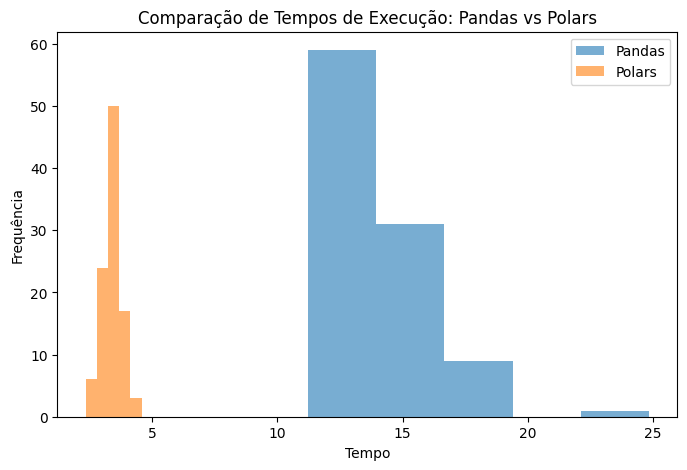

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
group1 = np.random.normal(0, 1, 1000)
group2 = np.random.normal(1, 1, 1000)

plt.figure(figsize=(8, 5))

plt.hist(tempos_pandas, bins=5, alpha=0.6, label='Pandas')
plt.hist(tempos_polars, bins=5, alpha=0.6, label='Polars')

plt.xlabel("Tempo")
plt.ylabel("Frequência")
plt.title("Comparação de Tempos de Execução: Pandas vs Polars")
plt.legend()

plt.show()